In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import adfuller

In [123]:
df= pd.read_csv("inputData_EWA_EWC (1).csv")
date= pd.to_datetime(df['Date'],format= '%Y%m%d')
Australia= df['EWA']
Canada= df['EWC']

0.9575322660751621


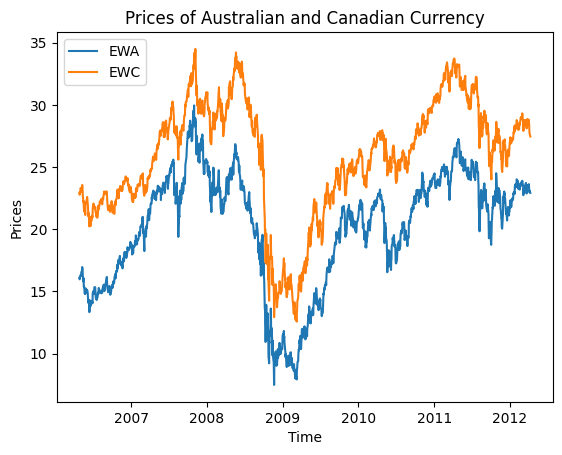

In [124]:
plt.plot(date,Australia, label='EWA')
plt.plot(date, Canada, label= 'EWC')
plt.legend()
plt.title("Prices of Australian and Canadian Currency")
plt.xlabel("Time")
plt.ylabel("Prices")
# now calculating the correlation coefficient
correlation = Australia.corr(Canada)
print(correlation)

the hedge ratio beta is  0.9526600515607517
we take EWA= beta*EWC + intercept


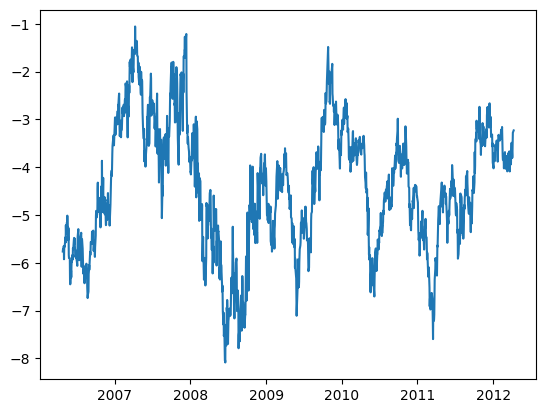

In [125]:
y= Australia
x= Canada
model= LinearRegression()
model.fit(df[['EWC']],df['EWA'])
inter= model.intercept_
slope= model.coef_[0]
# the hedge ratio is slope
beta= slope
print("the hedge ratio beta is ", beta)
print("we take EWA= beta*EWC + intercept")
spread= Australia- beta*Canada
plt.plot(date, daily_value)

In [126]:
adf= adfuller(spread, maxlag=1, regression= 'n')
t_test= adf[0]
p_value= adf[1]
critical_value= adf[4]
print("The t test result is", t_test)
print("The p value is", p_value)
print("The critical value is", critical_value['5%'])
# now for checking whether spread is mean reverting(stationary) or not we need to check the p vlaue with our threshold p value and since our confidence interval is 95% our p value is 0.05 and in the ADF test we say that the null hypothesis is that the time series is not stationary or has a unit root
if(p_value < 0.05):
  print("The spread is mean reverting or stationary")
else:
  print("The spread is not mean reverting")

The t test result is -1.290990801067248
The p value is 0.1815619338526065
The critical value is -1.941180796004319
The spread is not mean reverting


In [127]:
# Now assuming the spread is mean reverting calculating its half life i.e the time it takes for the spread to come half way to its mean
spread_lag= spread.shift(1)
spread_diff= spread- spread_lag
spread_diff= spread_diff.dropna()
spread_lag= spread_lag.dropna()
spread_lag= sm.add_constant(spread_lag)
model = sm.OLS(spread_diff,spread_lag).fit()
lambda_ = model.params.iloc[1]
half_life= -np.log(2)/lambda_
print("Half life of the spread is", half_life)

Half life of the spread is 27.95090884415413
